In [1]:
import pandas as pd
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, LearningCurveDisplay
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('ggplot')

In [2]:
result = pyreadr.read_r("listings.RData")
data = result['listings']
data.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [3]:
data['price'] = data['price'].astype(str)
data['price'] = data['price'].str.replace('$', '', regex=False)
data['price'] = data['price'].str.replace(',', '', regex=False)
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data = data.dropna(subset=['price'])

data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata', 'media', 'cara'])

print("Distribución de categorías:")
print(data['price_cat'].value_counts().sort_index())
print(f"\nRangos de precio:")
print(pd.qcut(data['price'], 3).value_counts().sort_index())

Distribución de categorías:
price_cat
barata    25689
media     25153
cara      25404
Name: count, dtype: int64

Rangos de precio:
price
(7.999, 143.0]      25689
(143.0, 268.0]      25153
(268.0, 50123.0]    25404
Name: count, dtype: int64


In [4]:
data['es_cara']   = (data['price_cat'] == 'cara').astype(int)
data['es_media']  = (data['price_cat'] == 'media').astype(int)
data['es_barata'] = (data['price_cat'] == 'barata').astype(int)

print(data[['price', 'price_cat', 'es_cara', 'es_media', 'es_barata']].head(10))

   price price_cat  es_cara  es_media  es_barata
0   97.0    barata        0         0          1
1  160.0     media        0         1          0
2   38.0    barata        0         0          1
3  145.0     media        0         1          0
4   58.0    barata        0         0          1
5   49.0    barata        0         0          1
6  300.0      cara        1         0          0
7  150.0     media        0         1          0
8  165.0     media        0         1          0
9  117.0    barata        0         0          1


In [5]:
X = data[['accommodates', 'bathrooms', 'bedrooms', 'beds',
          'minimum_nights', 'number_of_reviews', 'review_scores_rating']]

X = X.dropna()
y = data['es_cara'][X.index]

print(f"Tamaño de X: {X.shape}")
print(f"Distribución de y (es_cara):")
print(y.value_counts())

Tamaño de X: (62722, 7)
Distribución de y (es_cara):
es_cara
0    43784
1    18938
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts())

Entrenamiento: 43905 filas
Prueba:        18817 filas

Distribución en entrenamiento:
es_cara
0    30732
1    13173
Name: count, dtype: int64


In [7]:
logReg = LogisticRegression(solver='liblinear', random_state=42)
logReg.fit(X_train, y_train)

cv_scores = cross_val_score(logReg, X_train, y_train, cv=5, scoring='accuracy')

print("=== REGRESIÓN LOGÍSTICA ===")
print(f"\nValidación cruzada (5 folds):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nPromedio CV : {cv_scores.mean():.4f}")
print(f"Desv. std   : {cv_scores.std():.4f}")

print(f"\nCoeficientes del modelo:")
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': logReg.coef_[0]
}).sort_values('Coeficiente', ascending=False)
print(coef_df)

=== REGRESIÓN LOGÍSTICA ===

Validación cruzada (5 folds):
  Fold 1: 0.7907
  Fold 2: 0.7907
  Fold 3: 0.7983
  Fold 4: 0.7892
  Fold 5: 0.7932

Promedio CV : 0.7924
Desv. std   : 0.0032

Coeficientes del modelo:
               Variable  Coeficiente
1             bathrooms     0.794939
6  review_scores_rating     0.514315
0          accommodates     0.174099
2              bedrooms     0.132596
3                  beds     0.087829
5     number_of_reviews    -0.004404
4        minimum_nights    -0.011112


In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.astype(float)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("=== ANÁLISIS DE MULTICOLINEALIDAD (VIF) ===")
print(vif_data)
print("\nInterpretación:")
print("VIF < 5  → sin multicolinealidad")
print("VIF 5-10 → multicolinealidad moderada")
print("VIF > 10 → multicolinealidad alta (problema)")

=== ANÁLISIS DE MULTICOLINEALIDAD (VIF) ===
               Variable        VIF
0          accommodates  17.804823
2              bedrooms  11.408927
3                  beds  11.063951
1             bathrooms   9.781066
6  review_scores_rating   5.954905
5     number_of_reviews   1.477000
4        minimum_nights   1.237445

Interpretación:
VIF < 5  → sin multicolinealidad
VIF 5-10 → multicolinealidad moderada
VIF > 10 → multicolinealidad alta (problema)


In [9]:
print(X.corr().round(2))

                      accommodates  bathrooms  bedrooms  beds  minimum_nights  \
accommodates                  1.00       0.70      0.82  0.85           -0.12   
bathrooms                     0.70       1.00      0.75  0.67           -0.04   
bedrooms                      0.82       0.75      1.00  0.79           -0.04   
beds                          0.85       0.67      0.79  1.00           -0.08   
minimum_nights               -0.12      -0.04     -0.04 -0.08            1.00   
number_of_reviews            -0.10      -0.14     -0.11 -0.08           -0.12   
review_scores_rating          0.06       0.05      0.08  0.06           -0.03   

                      number_of_reviews  review_scores_rating  
accommodates                      -0.10                  0.06  
bathrooms                         -0.14                  0.05  
bedrooms                          -0.11                  0.08  
beds                              -0.08                  0.06  
minimum_nights                 

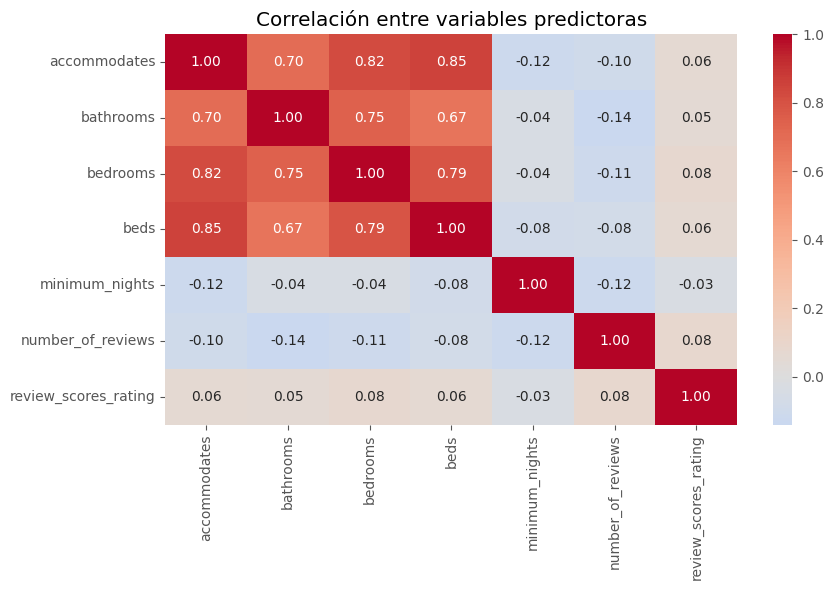

In [10]:
plt.figure(figsize=(9, 6))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre variables predictoras')
plt.tight_layout()
plt.show()

In [11]:
print("=== VARIABLES Y SU APORTE AL MODELO ===")
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': logReg.coef_[0]
}).sort_values('Coeficiente', ascending=False)

coef_df['Impacto'] = coef_df['Coeficiente'].apply(
    lambda x: 'Positivo (sube probabilidad de cara)' if x > 0 
    else 'Negativo (baja probabilidad de cara)'
)
print(coef_df.to_string(index=False))

=== VARIABLES Y SU APORTE AL MODELO ===
            Variable  Coeficiente                              Impacto
           bathrooms     0.794939 Positivo (sube probabilidad de cara)
review_scores_rating     0.514315 Positivo (sube probabilidad de cara)
        accommodates     0.174099 Positivo (sube probabilidad de cara)
            bedrooms     0.132596 Positivo (sube probabilidad de cara)
                beds     0.087829 Positivo (sube probabilidad de cara)
   number_of_reviews    -0.004404 Negativo (baja probabilidad de cara)
      minimum_nights    -0.011112 Negativo (baja probabilidad de cara)


In [12]:
y_pred = logReg.predict(X_test)

print("=== RESULTADOS EN CONJUNTO DE PRUEBA ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No cara', 'Cara']))

=== RESULTADOS EN CONJUNTO DE PRUEBA ===
Accuracy: 0.7908

              precision    recall  f1-score   support

     No cara       0.80      0.92      0.86     13052
        Cara       0.74      0.49      0.59      5765

    accuracy                           0.79     18817
   macro avg       0.77      0.71      0.72     18817
weighted avg       0.78      0.79      0.78     18817



In [13]:
y_pred_train = logReg.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred)

print("=== ANÁLISIS DE SOBREAJUSTE ===")
print(f"Accuracy Entrenamiento : {acc_train:.4f}")
print(f"Accuracy Prueba        : {acc_test:.4f}")
print(f"Diferencia             : {abs(acc_train - acc_test):.4f}")

if abs(acc_train - acc_test) > 0.05:
    print("Posible sobreajuste")
else:
    print("El modelo generaliza adecuadamente, sin sobreajuste")

=== ANÁLISIS DE SOBREAJUSTE ===
Accuracy Entrenamiento : 0.7926
Accuracy Prueba        : 0.7908
Diferencia             : 0.0019
El modelo generaliza adecuadamente, sin sobreajuste


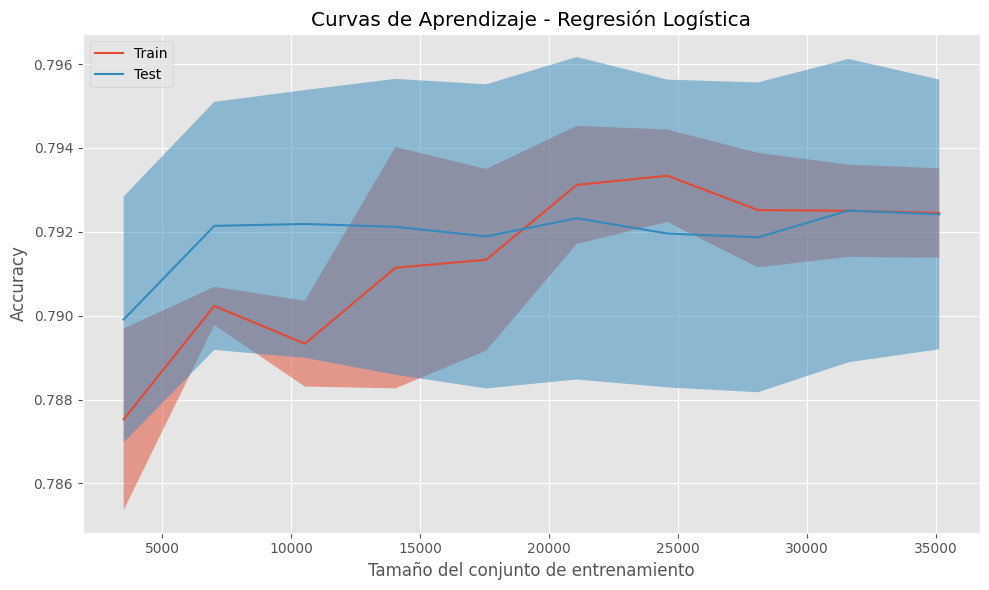

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

LearningCurveDisplay.from_estimator(
    logReg, X_train, y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    ax=ax
)

ax.set_title('Curvas de Aprendizaje - Regresión Logística')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = logReg.predict_proba(X_test)[:, 1]

print("=== ANÁLISIS DE THRESHOLD ===")
thresholds_test = [0.3, 0.4, 0.5, 0.6, 0.7]
for t in thresholds_test:
    y_pred_t = (y_prob >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    report = classification_report(y_test, y_pred_t, 
                                   target_names=['No cara','Cara'], 
                                   output_dict=True)
    print(f"\nThreshold = {t}")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Recall Cara       : {report['Cara']['recall']:.4f}")
    print(f"  Precision Cara    : {report['Cara']['precision']:.4f}")

=== ANÁLISIS DE THRESHOLD ===

Threshold = 0.3
  Accuracy          : 0.7704
  Recall Cara       : 0.7523
  Precision Cara    : 0.5999

Threshold = 0.4
  Accuracy          : 0.7894
  Recall Cara       : 0.6430
  Precision Cara    : 0.6605

Threshold = 0.5
  Accuracy          : 0.7908
  Recall Cara       : 0.4893
  Precision Cara    : 0.7396

Threshold = 0.6
  Accuracy          : 0.7786
  Recall Cara       : 0.3755
  Precision Cara    : 0.7927

Threshold = 0.7
  Accuracy          : 0.7668
  Recall Cara       : 0.2952
  Precision Cara    : 0.8397


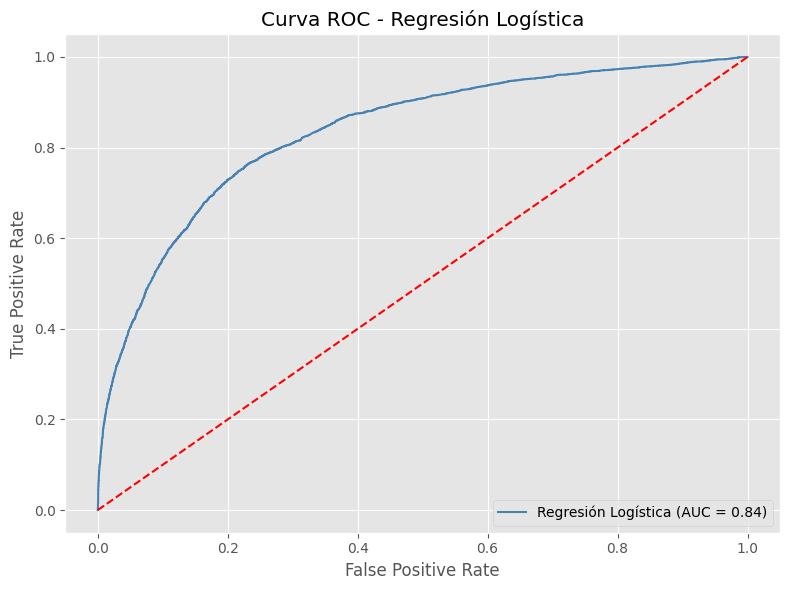

AUC: 0.8350


In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'Regresión Logística (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

In [17]:
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV

solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]

grid = dict(solver=solvers, penalty=penalty, C=c_values)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

grid_search = GridSearchCV(estimator=LogisticRegression(random_state=42), 
                           param_grid=grid, 
                           n_jobs=-1, cv=cv, 
                           scoring='accuracy', 
                           error_score=0)
grid_result = grid_search.fit(X_train, y_train)

print("=== TUNEO DE REGRESIÓN LOGÍSTICA ===")
print(f"Mejor accuracy (CV): {grid_result.best_score_:.4f}")
print(f"Mejores parámetros : {grid_result.best_params_}")

=== TUNEO DE REGRESIÓN LOGÍSTICA ===
Mejor accuracy (CV): 0.7930
Mejores parámetros : {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}


c:\Users\hugob\OneDrive\Desktop\clases\mineria_de_datos\laboratorio-7-Regresi-n-log-stica\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [18]:
best_model = grid_result.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("=== MEJOR MODELO (TUNEADO) EN CONJUNTO DE PRUEBA ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['No cara', 'Cara']))

=== MEJOR MODELO (TUNEADO) EN CONJUNTO DE PRUEBA ===
Accuracy: 0.7915

              precision    recall  f1-score   support

     No cara       0.80      0.92      0.86     13052
        Cara       0.74      0.49      0.59      5765

    accuracy                           0.79     18817
   macro avg       0.77      0.71      0.73     18817
weighted avg       0.78      0.79      0.78     18817



=== MATRIZ DE CONFUSIÓN ===
               Pred: No cara  Pred: Cara
Real: No cara          12051        1001
Real: Cara              2923        2842


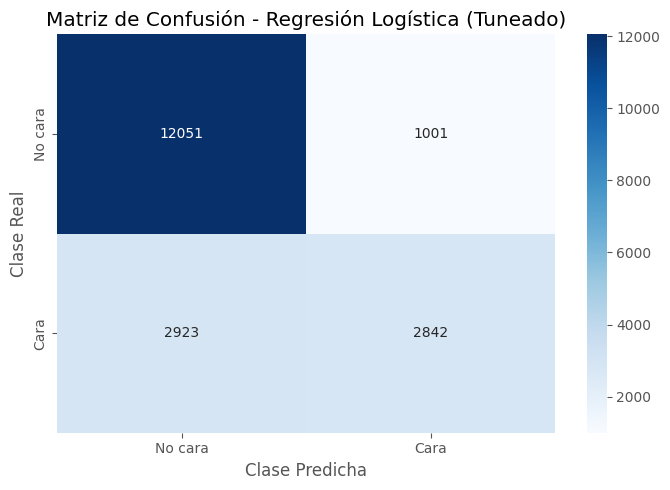


Verdaderos Negativos (TN) : 12051  → predijo No cara y era No cara
Falsos Positivos (FP)     : 1001  → predijo Cara pero era No cara
Falsos Negativos (FN)     : 2923  → predijo No cara pero era Cara
Verdaderos Positivos (TP) : 2842  → predijo Cara y era Cara


In [20]:
cm = confusion_matrix(y_test, y_pred_tuned)
cm_df = pd.DataFrame(cm,
                     index=['Real: No cara', 'Real: Cara'],
                     columns=['Pred: No cara', 'Pred: Cara'])

print("=== MATRIZ DE CONFUSIÓN ===")
print(cm_df)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No cara', 'Cara'],
            yticklabels=['No cara', 'Cara'])
plt.title('Matriz de Confusión - Regresión Logística (Tuneado)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nVerdaderos Negativos (TN) : {tn}  → predijo No cara y era No cara")
print(f"Falsos Positivos (FP)     : {fp}  → predijo Cara pero era No cara")
print(f"Falsos Negativos (FN)     : {fn}  → predijo No cara pero era Cara")
print(f"Verdaderos Positivos (TP) : {tp}  → predijo Cara y era Cara")

In [21]:
import time

modelos = {
    'LR Base': LogisticRegression(solver='liblinear', random_state=42),
    'LR Tuneado': best_model
}

resultados = []
for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tiempo = time.time() - inicio
    
    y_p = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_p)
    
    n = len(y_train)
    k = X_train.shape[1]
    log_loss_val = -np.mean(y_train * np.log(modelo.predict_proba(X_train)[:,1] + 1e-10) + 
                            (1-y_train) * np.log(1 - modelo.predict_proba(X_train)[:,1] + 1e-10))
    aic = 2*k - 2*(-n*log_loss_val)
    bic = k*np.log(n) - 2*(-n*log_loss_val)
    
    resultados.append({'Modelo': nombre, 'Accuracy': acc, 
                       'AIC': aic, 'BIC': bic, 'Tiempo(s)': round(tiempo, 4)})

tabla = pd.DataFrame(resultados)
print("=== COMPARACIÓN DE MODELOS ===")
print(tabla.to_string(index=False))
print("\nMenor AIC/BIC = mejor modelo")

=== COMPARACIÓN DE MODELOS ===
    Modelo  Accuracy          AIC          BIC  Tiempo(s)
   LR Base  0.790774 39770.874250 39831.702734     0.1031
LR Tuneado  0.791465 39768.903218 39829.731702     0.1076

Menor AIC/BIC = mejor modelo


c:\Users\hugob\OneDrive\Desktop\clases\mineria_de_datos\laboratorio-7-Regresi-n-log-stica\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [22]:
from sklearn.tree import DecisionTreeClassifier

inicio = time.time()
arbol = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
arbol.fit(X_train, y_train)
tiempo_arbol = time.time() - inicio

y_pred_arbol = arbol.predict(X_test)

print("=== ÁRBOL DE DECISIÓN ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_arbol):.4f}")
print(f"Tiempo   : {tiempo_arbol:.4f} segundos")
print()
print(classification_report(y_test, y_pred_arbol, target_names=['No cara', 'Cara']))

=== ÁRBOL DE DECISIÓN ===
Accuracy : 0.7868
Tiempo   : 0.0239 segundos

              precision    recall  f1-score   support

     No cara       0.81      0.91      0.86     13052
        Cara       0.71      0.51      0.59      5765

    accuracy                           0.79     18817
   macro avg       0.76      0.71      0.72     18817
weighted avg       0.78      0.79      0.78     18817



In [23]:
from sklearn.ensemble import RandomForestClassifier

inicio = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
tiempo_rf = time.time() - inicio

y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Tiempo   : {tiempo_rf:.4f} segundos")
print()
print(classification_report(y_test, y_pred_rf, target_names=['No cara', 'Cara']))

=== RANDOM FOREST ===
Accuracy : 0.7938
Tiempo   : 1.9394 segundos

              precision    recall  f1-score   support

     No cara       0.83      0.88      0.86     13052
        Cara       0.69      0.60      0.64      5765

    accuracy                           0.79     18817
   macro avg       0.76      0.74      0.75     18817
weighted avg       0.79      0.79      0.79     18817



In [24]:
from sklearn.naive_bayes import GaussianNB

inicio = time.time()
nb = GaussianNB()
nb.fit(X_train, y_train)
tiempo_nb = time.time() - inicio

y_pred_nb = nb.predict(X_test)

print("=== NAIVE BAYES ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Tiempo   : {tiempo_nb:.4f} segundos")
print()
print(classification_report(y_test, y_pred_nb, target_names=['No cara', 'Cara']))

=== NAIVE BAYES ===
Accuracy : 0.7867
Tiempo   : 0.0114 segundos

              precision    recall  f1-score   support

     No cara       0.82      0.89      0.85     13052
        Cara       0.69      0.55      0.61      5765

    accuracy                           0.79     18817
   macro avg       0.75      0.72      0.73     18817
weighted avg       0.78      0.79      0.78     18817



In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

inicio = time.time()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=39, p=1, metric='minkowski')
knn.fit(X_train_scaled, y_train)
tiempo_knn = time.time() - inicio

y_pred_knn = knn.predict(X_test_scaled)

print("=== KNN ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Tiempo   : {tiempo_knn:.4f} segundos")
print()
print(classification_report(y_test, y_pred_knn, target_names=['No cara', 'Cara']))

=== KNN ===
Accuracy : 0.8047
Tiempo   : 0.0589 segundos

              precision    recall  f1-score   support

     No cara       0.83      0.90      0.86     13052
        Cara       0.72      0.59      0.65      5765

    accuracy                           0.80     18817
   macro avg       0.78      0.75      0.76     18817
weighted avg       0.80      0.80      0.80     18817



=== COMPARACIÓN FINAL DE MODELOS ===
        Modelo  Accuracy  Precision Cara  Recall Cara  F1 Cara  F1 Macro  Tiempo(s)
    LR Tuneado    0.7915          0.7395       0.4930   0.5916    0.7258     0.1076
Árbol Decisión    0.7868          0.7135       0.5084   0.5937    0.7246     0.0239
 Random Forest    0.7938          0.6889       0.5958   0.6390    0.7473     1.9394
   Naive Bayes    0.7867          0.6886       0.5544   0.6143    0.7334     0.0114
           KNN    0.8047          0.7203       0.5927   0.6503    0.7574     0.0589


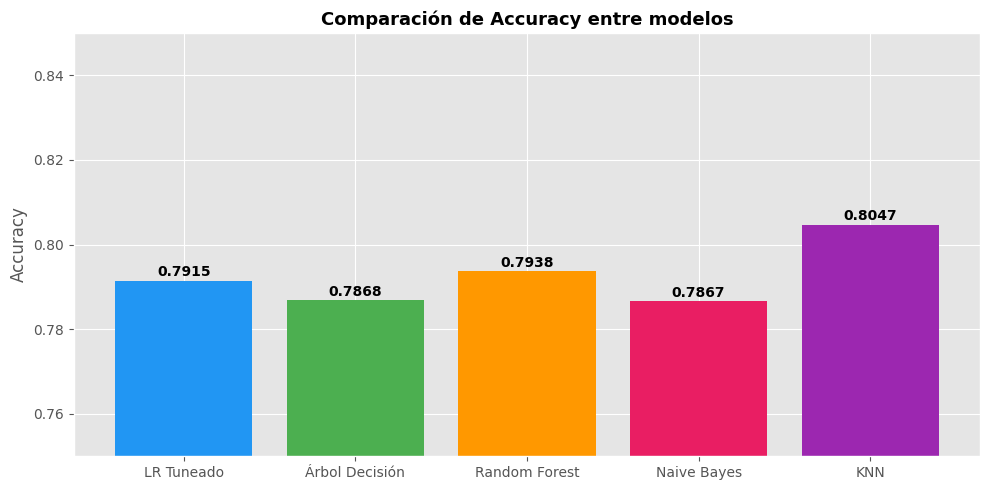

In [26]:
resultados_finales = {
    'LR Tuneado'      : (y_pred_tuned, 0.1076),
    'Árbol Decisión'  : (y_pred_arbol, 0.0239),
    'Random Forest'   : (y_pred_rf,    1.9394),
    'Naive Bayes'     : (y_pred_nb,    0.0114),
    'KNN'             : (y_pred_knn,   0.0589)
}

filas = []
for nombre, (pred, tiempo) in resultados_finales.items():
    report = classification_report(y_test, pred,
                                   target_names=['No cara', 'Cara'],
                                   output_dict=True)
    filas.append({
        'Modelo'         : nombre,
        'Accuracy'       : round(accuracy_score(y_test, pred), 4),
        'Precision Cara' : round(report['Cara']['precision'], 4),
        'Recall Cara'    : round(report['Cara']['recall'], 4),
        'F1 Cara'        : round(report['Cara']['f1-score'], 4),
        'F1 Macro'       : round(report['macro avg']['f1-score'], 4),
        'Tiempo(s)'      : tiempo
    })

tabla_final = pd.DataFrame(filas)
print("=== COMPARACIÓN FINAL DE MODELOS ===")
print(tabla_final.to_string(index=False))

plt.figure(figsize=(10, 5))
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
bars = plt.bar(tabla_final['Modelo'], tabla_final['Accuracy'], color=colores)
plt.title('Comparación de Accuracy entre modelos', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0.75, 0.85)
for bar, val in zip(bars, tabla_final['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.001,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()